In [1]:
import sys, os
sys.path.insert(0, r"C:\Users\Dell\Desktop\Rihliq\backend")

print("CWD:", os.getcwd())
print("models/__init__.py exists:", os.path.exists(r"C:\Users\Dell\Desktop\Rihliq\backend\models\__init__.py"))
print("schemas.py exists:", os.path.exists(r"C:\Users\Dell\Desktop\Rihliq\backend\models\schemas.py"))

import models.schemas as s
print("File loaded:", s.__file__)
print("Has AgentState:", hasattr(s, "AgentState"))
print("Names:", [n for n in dir(s) if not n.startswith("_")])

CWD: c:\Users\Dell\Desktop\Rihliq\backend
models/__init__.py exists: True
schemas.py exists: True
File loaded: C:\Users\Dell\Desktop\Rihliq\backend\models\schemas.py
Has AgentState: True
Names: ['AgentState', 'Annotated', 'Any', 'BaseModel', 'ChatRequest', 'Dict', 'Field', 'Flight', 'FlightBaggage', 'FlightSearchRequest', 'Hotel', 'HotelSearchRequest', 'List', 'Literal', 'Location', 'Optional', 'Restaurant', 'RestaurantSearchRequest', 'TripDetails', 'TripParseRequest', 'TripSelections', 'TripSlots', 'Union', 'add_messages', 'annotations']


In [4]:
import os
import logging
from datetime import date
from typing import Dict, Optional
from datetime import datetime, timedelta
from dotenv import load_dotenv
from pydantic import BaseModel

from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.messages import SystemMessage, HumanMessage, AIMessage
from langgraph.graph import StateGraph, END
from langgraph.checkpoint.memory import MemorySaver


from models.schemas import (
    AgentState, TripSlots, TripSelections,
    FlightSearchRequest, HotelSearchRequest, RestaurantSearchRequest,
)
from services.flight_service import search_flights, FlightSearchError
from services.hotel_service import search_hotels
from services.restaurant_service import search_restaurants
from langchain_groq import ChatGroq

load_dotenv()
logger = logging.getLogger(__name__)


# ─── LLM ──────────────────────────────────────────────────────────────────────

# def get_llm(temperature: float = 0) -> ChatGoogleGenerativeAI:
#     return ChatGoogleGenerativeAI(
#         model="gemini-2.5-flash-lite",
#         temperature=temperature,
#         api_key=os.getenv("GOOGLE_API_KEY"),
#     )

def get_llm(temperature: float = 0) -> ChatGroq:
    return ChatGroq(
        model="llama-3.3-70b-versatile",
        temperature=temperature,
        api_key=os.getenv("GROQ_API_KEY"),
    )


# ─── EXTRACTION SCHEMA ────────────────────────────────────────────────────────

class ExtractionResult(BaseModel):
    slots: TripSlots
    selections: TripSelections
    user_wants_next_phase: Optional[bool] = None  # kept for compatibility, can remove later
    user_pick: Optional[str] = None
    trip_confirmed: Optional[bool] = None
    hotels_confirmed: Optional[bool] = None
    restaurants_confirmed: Optional[bool] = None


SYSTEM_EXTRACT = """You extract structured data for a travel assistant. You never chat.

Rules:
- Preserve existing values unless the user changes them.
- Dates: YYYY-MM-DD, or null if only a month given. "next week" = 7 days from today.
- num_nights: "5 nights"→5, "a week"→7, "weekend"→2, "3 days"→3.
- num_travelers: "me and my wife"→2, "family of 4"→4, "alone"→1.

INTENT DETECTION (set these based on what the user wants help with):
- wants_flights=true if user mentions flights, flying, plane tickets, booking a flight, or a full trip.
- wants_hotels=true if user mentions hotels, accommodation, place to stay, or a full trip.
- wants_restaurants=true if user mentions restaurants, places to eat, food, dining, or a full trip.
- If user says "plan my trip" or similar → all three true.
- Once an intent is true, NEVER reset it to false unless user explicitly drops that phase.

CONFIRMATIONS:
- trip_confirmed=true if user confirms flight trip details ("yes", "correct", "go ahead").
- hotels_confirmed=true if user confirms hotel search ("yes find hotels", "go ahead with hotels").
- restaurants_confirmed=true if user confirms restaurant search.

- cuisine_preference: capture if user mentions "italian", "moroccan food", "seafood", etc.
- If user picks an option, put raw text in user_pick ("2", "the Moxy", etc.)."""

# ─── HELPERS ──────────────────────────────────────────────────────────────────

def _last_user_text(state: AgentState) -> str:
    for m in reversed(state.messages):
        if isinstance(m, HumanMessage):
            return m.content
    return ""


def _merge(old: BaseModel, new: BaseModel) -> BaseModel:
    """Keep old values when new ones are empty."""
    merged = old.model_dump()
    for k, v in new.model_dump().items():
        if v not in (None, "", [], 0):
            merged[k] = v
    return type(old)(**merged)

def resolve_pick(pick: str, items: list) -> Optional[str]:
    """Match user input to an item id. Tries number, exact id, then name substring."""
    if not pick or not items:
        return None
    pick = pick.strip().lower()

    # Try: "2" → items[1].id
    if pick.isdigit():
        idx = int(pick) - 1
        if 0 <= idx < len(items):
            return items[idx].id

    # Try: exact id match
    for item in items:
        if item.id.lower() == pick:
            return item.id

    # Try: name substring match
    for item in items:
        name = getattr(item, "name", None) or getattr(item, "airline", "")
        if pick in name.lower():
            return item.id

    return None


# ─── NODES ────────────────────────────────────────────────────────────────────

# ─── CHAT PERSONALITY ────────────────────────────────────────────────────────

CHAT_SYSTEM = """You are RihlIQ, a warm, enthusiastic travel concierge. You talk like a friendly human, not a form.

Your rules:
- Keep replies to 1-3 short sentences. No bullet lists, no markdown headers.
- Acknowledge what the user just told you before asking the next thing.
- If brief says "STILL NEED", ask ONE natural question about that item.
- If brief says "READY TO CONFIRM", summarize in one sentence and ask if it's correct.
- If brief says "FOUND", present the top 3 options like a friend would, then ask which they like.
- If brief says "PICKED", acknowledge warmly and mention what's next if another phase is active.
- If brief says "ALL DONE", warmly wrap up.
- If brief says user wants unknown, ask openly what they'd like help with.
- Never invent details — only use what's in the brief."""


def _chat_brief(state: AgentState) -> str:
    """Build a compact internal brief for the chat LLM."""
    s = state.slots
    sel = state.selections
    lines = []

    # ── Intent
    intents = []
    if s.wants_flights: intents.append("flights")
    if s.wants_hotels: intents.append("hotels")
    if s.wants_restaurants: intents.append("restaurants")
    if intents:
        lines.append(f"USER WANTS: {', '.join(intents)}")
    else:
        lines.append("USER WANTS: unknown — ask openly what kind of help they need (flights, hotel, food, or full trip planning).")
        return "\n".join(lines)

    # ── Known info
    known = []
    if s.origin and s.destination:
        known.append(f"{s.origin} → {s.destination}")
    elif s.destination:
        known.append(f"destination: {s.destination}")
    if s.departure_date: known.append(f"depart {s.departure_date}")
    if s.num_nights: known.append(f"{s.num_nights} nights")
    if s.num_travelers and s.num_travelers > 1: known.append(f"{s.num_travelers} travelers")
    if s.cuisine_preference: known.append(f"cuisine: {s.cuisine_preference}")
    if known: lines.append("KNOWN: " + ", ".join(known))

    # ── FLIGHTS
    if s.wants_flights and not sel.selected_flight_id:
        missing = []
        if not s.origin: missing.append("origin city")
        if not s.destination: missing.append("destination city")
        if not s.departure_date: missing.append("departure date")
        if missing:
            lines.append(f"FLIGHTS — STILL NEED: {missing[0]}")
        elif not state.trip_confirmed and not state.flights:
            lines.append("FLIGHTS — READY TO CONFIRM: summarize flight trip details in one sentence and ask 'is that correct?'")
        elif state.flights and not sel.selected_flight_id:
            top = state.flights[:3]
            fl = []
            for i, f in enumerate(top, 1):
                stops = "direct" if f.stops == 0 else f"{f.stops} stop(s)"
                dep = f.departure_time.replace("T", " ")[:16]
                fl.append(f"  {i}. {f.airline} {f.flight_number} | {dep} | {f.duration} | {stops} | {f.price:.0f} {f.currency}")
            lines.append(f"FLIGHTS FOUND ({len(state.flights)} total, top 3):\n" + "\n".join(fl))
    elif s.wants_flights and sel.selected_flight_id:
        f = next((x for x in state.flights if x.id == sel.selected_flight_id), None)
        if f:
            lines.append(f"FLIGHT PICKED: {f.airline} {f.flight_number} at {f.price:.0f} {f.currency}")

    # ── HOTELS
    if s.wants_hotels and not sel.selected_hotel_id:
        if not s.destination:
            lines.append("HOTELS — STILL NEED: destination city")
        elif not s.num_nights and not s.return_date:
            lines.append("HOTELS — STILL NEED: how many nights they'll stay")
        elif not state.hotels_confirmed and not state.hotels:
            lines.append(f"HOTELS — READY TO CONFIRM: ask 'want me to find hotels in {s.destination} for {s.num_nights} nights?'")
        elif state.hotels and not sel.selected_hotel_id:
            top = state.hotels[:3]
            hl = []
            for i, h in enumerate(top, 1):
                price = f"{h.cheapest_price:.0f} {h.currency}" if h.cheapest_price else "N/A"
                rating = f"{h.rating}★" if h.rating else "—"
                score = f"{h.review_score}/10" if h.review_score else ""
                hl.append(f"  {i}. {h.name} ({rating} {score}) | from {price}")
            lines.append(f"HOTELS FOUND ({len(state.hotels)} total, top 3):\n" + "\n".join(hl))
    elif s.wants_hotels and sel.selected_hotel_id:
        h = next((x for x in state.hotels if x.id == sel.selected_hotel_id), None)
        if h:
            lines.append(f"HOTEL PICKED: {h.name}")

    # ── RESTAURANTS
    if s.wants_restaurants and not state.restaurants:
        if not s.destination:
            lines.append("RESTAURANTS — STILL NEED: destination city")
        elif not state.restaurants_confirmed:
            cuisine_note = f" focused on {s.cuisine_preference}" if s.cuisine_preference else " (ask if they have a cuisine in mind, or just find top-rated)"
            lines.append(f"RESTAURANTS — READY TO CONFIRM: offer to find restaurants in {s.destination}{cuisine_note}")
    elif s.wants_restaurants and state.restaurants:
        top = state.restaurants[:3]
        rl = []
        for i, r in enumerate(top, 1):
            rating = f"{r.rating}★" if r.rating else "—"
            cuisine = r.cuisine or "—"
            rl.append(f"  {i}. {r.name} ({rating}, {cuisine})")
        lines.append(f"RESTAURANTS FOUND ({len(state.restaurants)} total, top 3):\n" + "\n".join(rl))

    # ── Done check
    all_done = True
    if s.wants_flights and not sel.selected_flight_id: all_done = False
    if s.wants_hotels and not sel.selected_hotel_id: all_done = False
    if s.wants_restaurants and not state.restaurants: all_done = False
    if all_done:
        lines.append("ALL DONE: warmly summarize what's been booked/saved and offer to help with anything else.")

    return "\n".join(lines)


async def chat_node(state: AgentState) -> Dict:
    """The warm, human voice of the agent — handles all phases conversationally."""
    llm = get_llm(0.7)
    brief = _chat_brief(state)
    history = state.messages[-8:] if state.messages else []

    response = await llm.ainvoke([
        SystemMessage(content=CHAT_SYSTEM),
        *history,
        HumanMessage(content=f"[Internal brief — do not mention to user]\n{brief}\n\nReply to the user now."),
    ])
    return {"messages": [AIMessage(content=response.content)], "next_question": response.content}

    # Flights phase → warm LLM-driven conversation
    llm = get_llm(0.7)
    brief = _chat_brief(state)
    history = state.messages[-8:] if state.messages else []

    response = await llm.ainvoke([
        SystemMessage(content=CHAT_SYSTEM),
        *history,
        HumanMessage(content=f"[Internal brief — do not mention to user]\n{brief}\n\nReply to the user now."),
    ])
    return {"messages": [AIMessage(content=response.content)], "next_question": response.content}

async def extractor_node(state: AgentState) -> Dict:
    llm = get_llm(0).with_structured_output(ExtractionResult)
    user_msg = _last_user_text(state)
    
    result: ExtractionResult = await llm.ainvoke([
        SystemMessage(content=SYSTEM_EXTRACT),
        HumanMessage(content=f"""Today: {date.today()}
Phase: {state.current_phase}
Slots: {state.slots.model_dump_json()}
Selections: {state.selections.model_dump_json()}
User said: "{user_msg}" """),
    ])

    new_selections = _merge(state.selections, result.selections)

    # Resolve user_pick based on current phase
    if result.user_pick:
        # Try all three — user might pick anything at any time
        flight_match = resolve_pick(result.user_pick, state.flights)
        hotel_match = resolve_pick(result.user_pick, state.hotels)
        if flight_match and not new_selections.selected_flight_id:
            new_selections.selected_flight_id = flight_match
        elif hotel_match and not new_selections.selected_hotel_id:
            new_selections.selected_hotel_id = hotel_match

    update = {
        "slots": _merge(state.slots, result.slots),
        "selections": new_selections,
    }
    if result.trip_confirmed is True:
        update["trip_confirmed"] = True
    if result.hotels_confirmed is True:
        update["hotels_confirmed"] = True
    if result.restaurants_confirmed is True:
        update["restaurants_confirmed"] = True
    return update


async def flight_search_node(state: AgentState) -> Dict:
    req = FlightSearchRequest(
        origin=state.slots.origin,
        destination=state.slots.destination,
        departure_date=state.slots.departure_date,
        return_date=state.slots.return_date,
        num_travelers=state.slots.num_travelers,
        travel_class=state.slots.travel_class,
    )
    try:
        flights = await search_flights(req)
    except FlightSearchError as e:
        msg = f"Hmm, I couldn't find flights — {e}. Could you double-check the cities and date?"
        return {"flights": [], "messages": [AIMessage(content=msg)], "next_question": msg}

    # Just return the data. chat_node will present it warmly.
    return {"flights": flights, "current_phase": "flights"}

async def hotel_search_node(state: AgentState) -> Dict:
    check_in = state.slots.departure_date
    if state.slots.return_date and state.slots.return_date > check_in:
        check_out = state.slots.return_date
    elif state.slots.num_nights:
        check_in_dt = datetime.strptime(check_in, "%Y-%m-%d")
        check_out = (check_in_dt + timedelta(days=state.slots.num_nights)).strftime("%Y-%m-%d")
    else:
        check_in_dt = datetime.strptime(check_in, "%Y-%m-%d")
        check_out = (check_in_dt + timedelta(days=3)).strftime("%Y-%m-%d")

    req = HotelSearchRequest(
        destination=state.slots.destination,
        check_in=check_in,
        check_out=check_out,
        num_guests=state.slots.num_travelers,
    )
    hotels = await search_hotels(req)
    return {"hotels": hotels}

async def restaurant_search_node(state: AgentState) -> Dict:
    query = state.slots.cuisine_preference or "Top rated"
    req = RestaurantSearchRequest(query=query, destination=state.slots.destination)
    restaurants = await search_restaurants(req)
    return {"restaurants": restaurants}


async def final_summary_node(state: AgentState) -> Dict:
    llm = get_llm(0.7)
    prompt = (
        f"Write a short, warm 3-sentence wrap-up for a trip to {state.slots.destination} "
        f"from {state.slots.origin} on {state.slots.departure_date}. "
        f"Flight picked: {state.selections.selected_flight_id}. "
        f"Hotel picked: {state.selections.selected_hotel_id}. "
        f"{len(state.restaurants)} restaurants saved."
    )
    res = await llm.ainvoke([HumanMessage(content=prompt)])
    return {
        "current_phase": "done",
        "is_complete": True,
        "messages": [AIMessage(content=res.content)],
        "next_question": res.content,
    }


# ─── ROUTER ───────────────────────────────────────────────────────────────────

def router(state: AgentState) -> str:
    s = state.slots
    sel = state.selections

    # No intent detected yet → chat asks what they want
    if not any([s.wants_flights, s.wants_hotels, s.wants_restaurants]):
        return "chat"

    # FLIGHTS
    if s.wants_flights and not sel.selected_flight_id:
        if not s.origin or not s.destination or not s.departure_date:
            return "chat"
        if not state.trip_confirmed:
            return "chat"
        if not state.flights:
            return "flight_search"
        return "chat"  # present flights, wait for pick

    # HOTELS
    if s.wants_hotels and not sel.selected_hotel_id:
        if not s.destination:
            return "chat"
        if not s.num_nights and not s.return_date:
            return "chat"
        if not state.hotels_confirmed:
            return "chat"
        if not state.hotels:
            return "hotel_search"
        return "chat"  # present hotels, wait for pick

    # RESTAURANTS
    if s.wants_restaurants and not state.restaurants:
        if not s.destination:
            return "chat"
        if not state.restaurants_confirmed:
            return "chat"
        return "restaurant_search"

    # Everything done
    return "chat"

# ─── GRAPH ────────────────────────────────────────────────────────────────────

def create_travel_graph():
    g = StateGraph(AgentState)

    g.add_node("extractor", extractor_node)
    g.add_node("chat", chat_node)
    g.add_node("flight_search", flight_search_node)
    g.add_node("hotel_search", hotel_search_node)
    g.add_node("restaurant_search", restaurant_search_node)

    g.set_entry_point("extractor")

    g.add_conditional_edges(
        "extractor",
        router,
        {
            "chat": "chat",
            "flight_search": "flight_search",
            "hotel_search": "hotel_search",
            "restaurant_search": "restaurant_search",
        },
    )

    # All tool nodes flow into chat, which presents results
    g.add_edge("flight_search", "chat")
    g.add_edge("hotel_search", "chat")
    g.add_edge("restaurant_search", "chat")

    g.add_edge("chat", END)

    return g.compile(checkpointer=MemorySaver())


# ─── INTERFACE ────────────────────────────────────────────────────────────────

class TravelAssistant:
    def __init__(self):
        self.graph = create_travel_graph()

    async def process_message(self, user_msg: str, thread_id: str) -> AgentState:
        config = {"configurable": {"thread_id": thread_id}}
        result = await self.graph.ainvoke(
            {"messages": [HumanMessage(content=user_msg)]},
            config=config,
        )
        return result if isinstance(result, AgentState) else AgentState(**result)


travel_assistant = TravelAssistant()

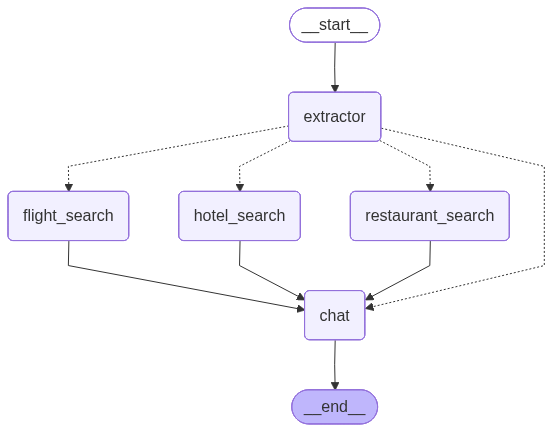

In [5]:
from IPython.display import Image, display

# inside your create_travel_graph() or after compiling:
display(Image(travel_assistant.graph.get_graph().draw_mermaid_png()))